# 🫀 Cardiovascular Disease Prediction — Final Data Science Project

**Dataset:** [Cardiovascular Disease Dataset — Kaggle (sulianova)](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset)  
**Domain:** Healthcare / Bioinformatics  
**Size:** 70,000 rows × 12 columns  
**Target:** Binary classification — presence (1) or absence (0) of cardiovascular disease

---

## Project Questions
1. **Can we predict whether a patient has cardiovascular disease based on clinical and lifestyle features?**
2. **Which features (age, cholesterol, blood pressure, BMI, lifestyle habits) are the strongest predictors of cardiovascular disease?**
3. **How do blood pressure and cholesterol interact with age to affect disease risk?**

---

## Step 1 — Project Understanding

Cardiovascular disease (CVD) is the leading cause of death globally, responsible for about 17.9 million deaths per year (WHO). Early detection using patient data can significantly reduce mortality. This project uses machine learning to build a predictive model from real patient examination data.

**Dataset columns:**
| Feature | Description |
|---|---|
| id | Patient ID |
| age | Age in days |
| gender | 1 = Female, 2 = Male |
| height | Height (cm) |
| weight | Weight (kg) |
| ap_hi | Systolic blood pressure |
| ap_lo | Diastolic blood pressure |
| cholesterol | 1: normal, 2: above normal, 3: well above normal |
| gluc | Glucose: 1: normal, 2: above normal, 3: well above normal |
| smoke | Smoker: 0/1 |
| alco | Alcohol intake: 0/1 |
| active | Physical activity: 0/1 |
| cardio | **Target** — CVD present: 0/1 |

## Step 2 — Data Mining & Processing (Data Cleaning)

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif, RFE

# Saving model
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#E63946', '#457B9D']
print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


In [3]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
# Download from: https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset
# Place 'cardio_train.csv' in the same directory as this notebook.

df = pd.read_csv('cardio_train.csv', sep=';')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
# ── Basic Info ────────────────────────────────────────────────────────────────
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB

=== Statistical Summary ===


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# ── Missing Values ────────────────────────────────────────────────────────────
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal missing values: {missing.sum()}')

=== Missing Values ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing values: 0


In [6]:
# ── Duplicate Check ───────────────────────────────────────────────────────────
print(f'Duplicate rows before cleaning: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Duplicate rows after cleaning:  {df.duplicated().sum()}')

Duplicate rows before cleaning: 0
Duplicate rows after cleaning:  0


In [7]:
# ── Data Quality Issues — Outlier Detection ───────────────────────────────────
# Blood pressure: physiologically impossible values
print('Blood Pressure - ap_hi range before:', df['ap_hi'].min(), 'to', df['ap_hi'].max())
print('Blood Pressure - ap_lo range before:', df['ap_lo'].min(), 'to', df['ap_lo'].max())
print('Height range before:', df['height'].min(), 'to', df['height'].max())
print('Weight range before:', df['weight'].min(), 'to', df['weight'].max())

Blood Pressure - ap_hi range before: -150 to 16020
Blood Pressure - ap_lo range before: -70 to 11000
Height range before: 55 to 250
Weight range before: 10.0 to 200.0


In [8]:
# ── Remove Physiologically Impossible Values ──────────────────────────────────
# Documentation: we remove rows with clinically impossible measurements

initial_rows = len(df)

# Systolic BP: valid range 60–250 mmHg
df = df[(df['ap_hi'] >= 60) & (df['ap_hi'] <= 250)]

# Diastolic BP: valid range 40–200 mmHg
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)]

# Systolic must be >= diastolic
df = df[df['ap_hi'] >= df['ap_lo']]

# Height: reasonable adult range 100–250 cm
df = df[(df['height'] >= 100) & (df['height'] <= 250)]

# Weight: reasonable adult range 30–200 kg
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

removed = initial_rows - len(df)
print(f'Rows removed due to impossible values: {removed} ({removed/initial_rows*100:.2f}%)')
print(f'Remaining rows: {len(df)}')

Rows removed due to impossible values: 1358 (1.94%)
Remaining rows: 68642


In [9]:
# ── Feature Engineering ───────────────────────────────────────────────────────
# NEW FEATURE 1: BMI — Body Mass Index (weight/height²)
df['bmi'] = df['weight'] / (df['height'] / 100) ** 2
df['bmi'] = df['bmi'].round(2)

# NEW FEATURE 2: Age in years (original is in days)
df['age_years'] = (df['age'] / 365).round(1)

# NEW FEATURE 3: Pulse pressure (systolic - diastolic)
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

# NEW FEATURE 4: Hypertension flag
df['hypertension'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)

# NEW FEATURE 5: Obesity flag (BMI >= 30)
df['obese'] = (df['bmi'] >= 30).astype(int)

print('New features added: bmi, age_years, pulse_pressure, hypertension, obese')
df[['bmi', 'age_years', 'pulse_pressure', 'hypertension', 'obese']].describe()

New features added: bmi, age_years, pulse_pressure, hypertension, obese


,bmi,age_years,pulse_pressure,hypertension,obese
count,68642.000000,68642.000000,68642.000000,68642.000000,68642.000000
mean,27.473394,53.328101,45.366802,0.342924,0.262318
std,5.351852,6.761950,11.669462,0.474690,0.439898
min,10.730000,29.600000,0.000000,0.000000,0.000000
25%,23.880000,48.400000,40.000000,0.000000,0.000000
50%,26.350000,54.000000,40.000000,0.000000,0.000000
75%,30.120000,58.400000,50.000000,1.000000,1.000000
max,152.550000,65.000000,140.000000,1.000000,1.000000


In [10]:
# ── Drop 'id' column (not a feature) ─────────────────────────────────────────
df.drop(columns=['id'], inplace=True)
print('Final cleaned dataframe shape:', df.shape)
df.head()

Final cleaned dataframe shape: (68642, 17)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,age_years,pulse_pressure,hypertension,obese
0,18393,2,168,62.0,110,80,1,1,0,0,1,0,21.97,50.4,30,0,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1,34.93,55.4,50,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1,23.51,51.7,60,0,0
3,17623,2,169,82.0,150,100,1,1,0,0,1,1,28.71,48.3,50,1,0
4,17474,1,156,56.0,100,60,1,1,0,0,0,0,23.01,47.9,40,0,0


## Step 3 — Data Exploration (EDA)

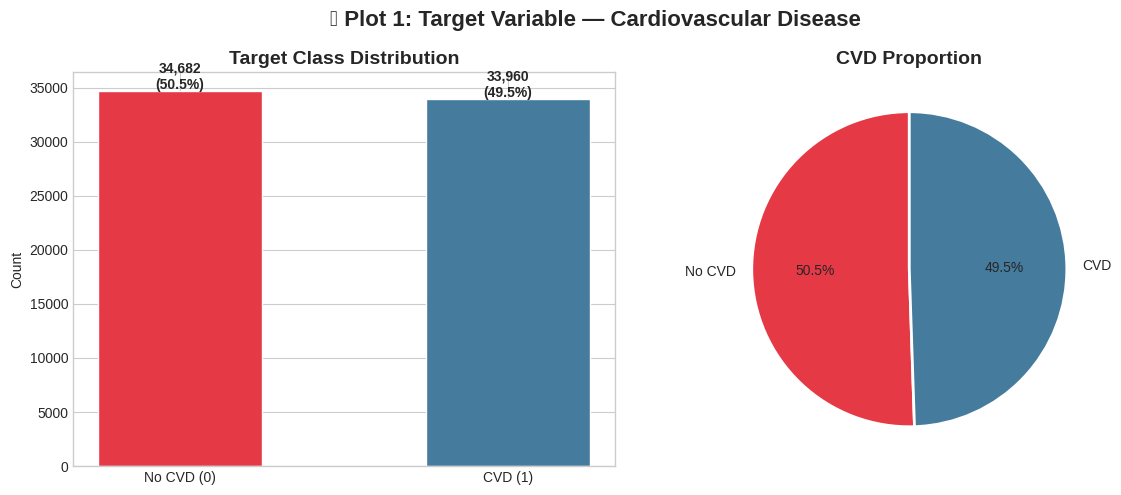

✅ Dataset is balanced — good for classification!


In [11]:
# ── Target Distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
cardio_counts = df['cardio'].value_counts()
axes[0].bar(['No CVD (0)', 'CVD (1)'], cardio_counts.values, color=PALETTE, edgecolor='white', width=0.5)
axes[0].set_title('Target Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(cardio_counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(cardio_counts.values, labels=['No CVD', 'CVD'],
            colors=PALETTE, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('CVD Proportion', fontsize=14, fontweight='bold')

plt.suptitle('📊 Plot 1: Target Variable — Cardiovascular Disease', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plot1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dataset is balanced — good for classification!')

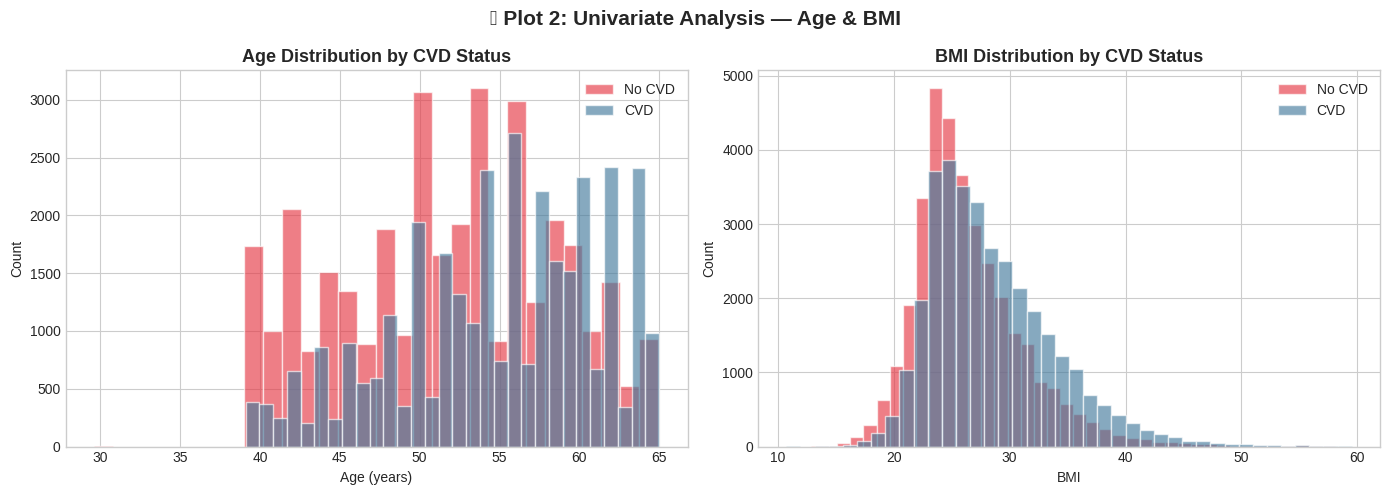

In [12]:
# ── Univariate Analysis — Age Distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram by class
for val, label, color in zip([0, 1], ['No CVD', 'CVD'], PALETTE):
    axes[0].hist(df[df['cardio'] == val]['age_years'], bins=30, alpha=0.65,
                 label=label, color=color, edgecolor='white')
axes[0].set_title('Age Distribution by CVD Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# BMI distribution
for val, label, color in zip([0, 1], ['No CVD', 'CVD'], PALETTE):
    subset = df[(df['cardio'] == val) & (df['bmi'] < 60)]
    axes[1].hist(subset['bmi'], bins=40, alpha=0.65,
                 label=label, color=color, edgecolor='white')
axes[1].set_title('BMI Distribution by CVD Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('📊 Plot 2: Univariate Analysis — Age & BMI', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_age_bmi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

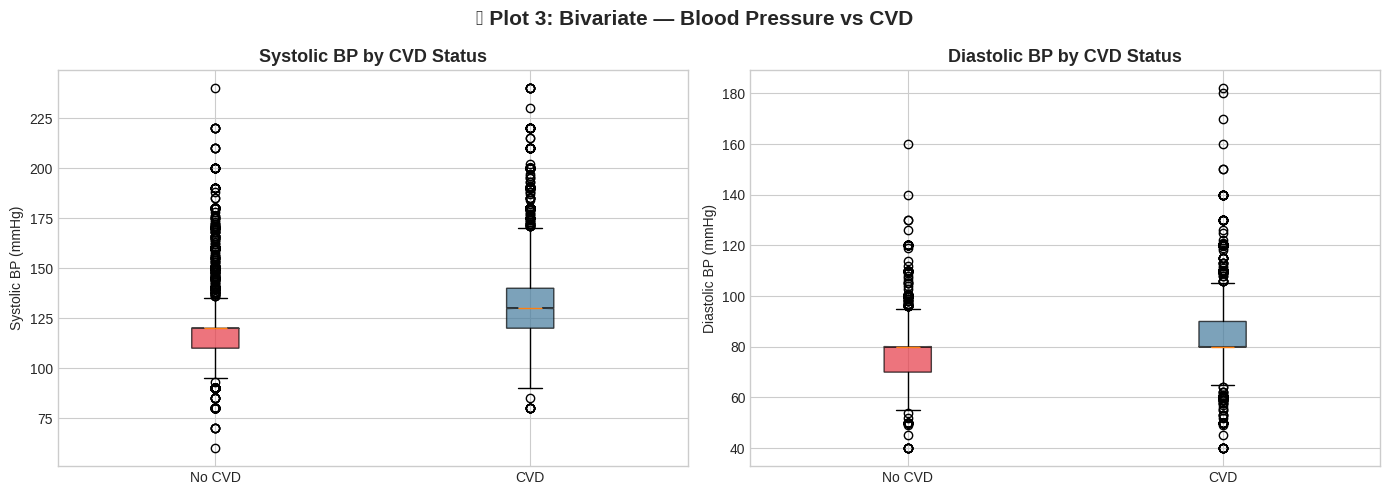

In [13]:
# ── Bivariate Analysis — Blood Pressure vs CVD ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: Systolic BP
bp_data = [df[df['cardio'] == 0]['ap_hi'], df[df['cardio'] == 1]['ap_hi']]
bp = axes[0].boxplot(bp_data, labels=['No CVD', 'CVD'],
                     patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Systolic BP by CVD Status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Systolic BP (mmHg)')

# Box plot: Diastolic BP
bp_data2 = [df[df['cardio'] == 0]['ap_lo'], df[df['cardio'] == 1]['ap_lo']]
bp2 = axes[1].boxplot(bp_data2, labels=['No CVD', 'CVD'],
                      patch_artist=True, notch=True)
for patch, color in zip(bp2['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Diastolic BP by CVD Status', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Diastolic BP (mmHg)')

plt.suptitle('📊 Plot 3: Bivariate — Blood Pressure vs CVD', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_blood_pressure_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

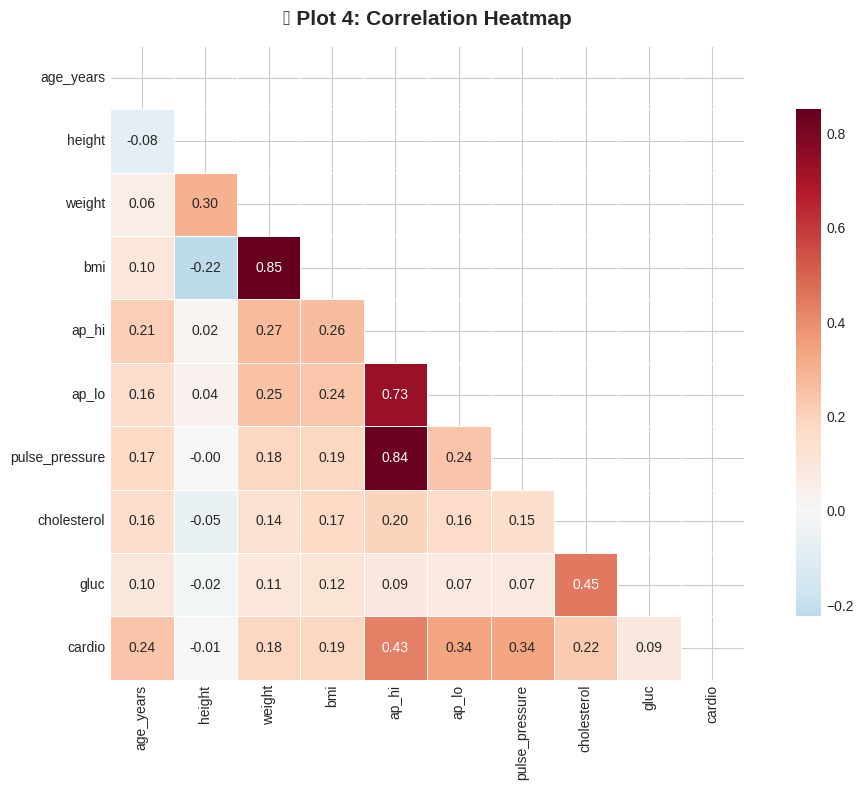


Top correlations with target (cardio):
cardio            1.000000
ap_hi             0.427998
ap_lo             0.340071
pulse_pressure    0.336810
age_years         0.239374
cholesterol       0.221441
bmi               0.186176
weight            0.179829
gluc              0.089558
height            0.011813
Name: cardio, dtype: float64


In [14]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
numerical_cols = ['age_years', 'height', 'weight', 'bmi', 'ap_hi', 'ap_lo',
                  'pulse_pressure', 'cholesterol', 'gluc', 'cardio']

plt.figure(figsize=(11, 8))
corr_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('📊 Plot 4: Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTop correlations with target (cardio):')
print(corr_matrix['cardio'].abs().sort_values(ascending=False))

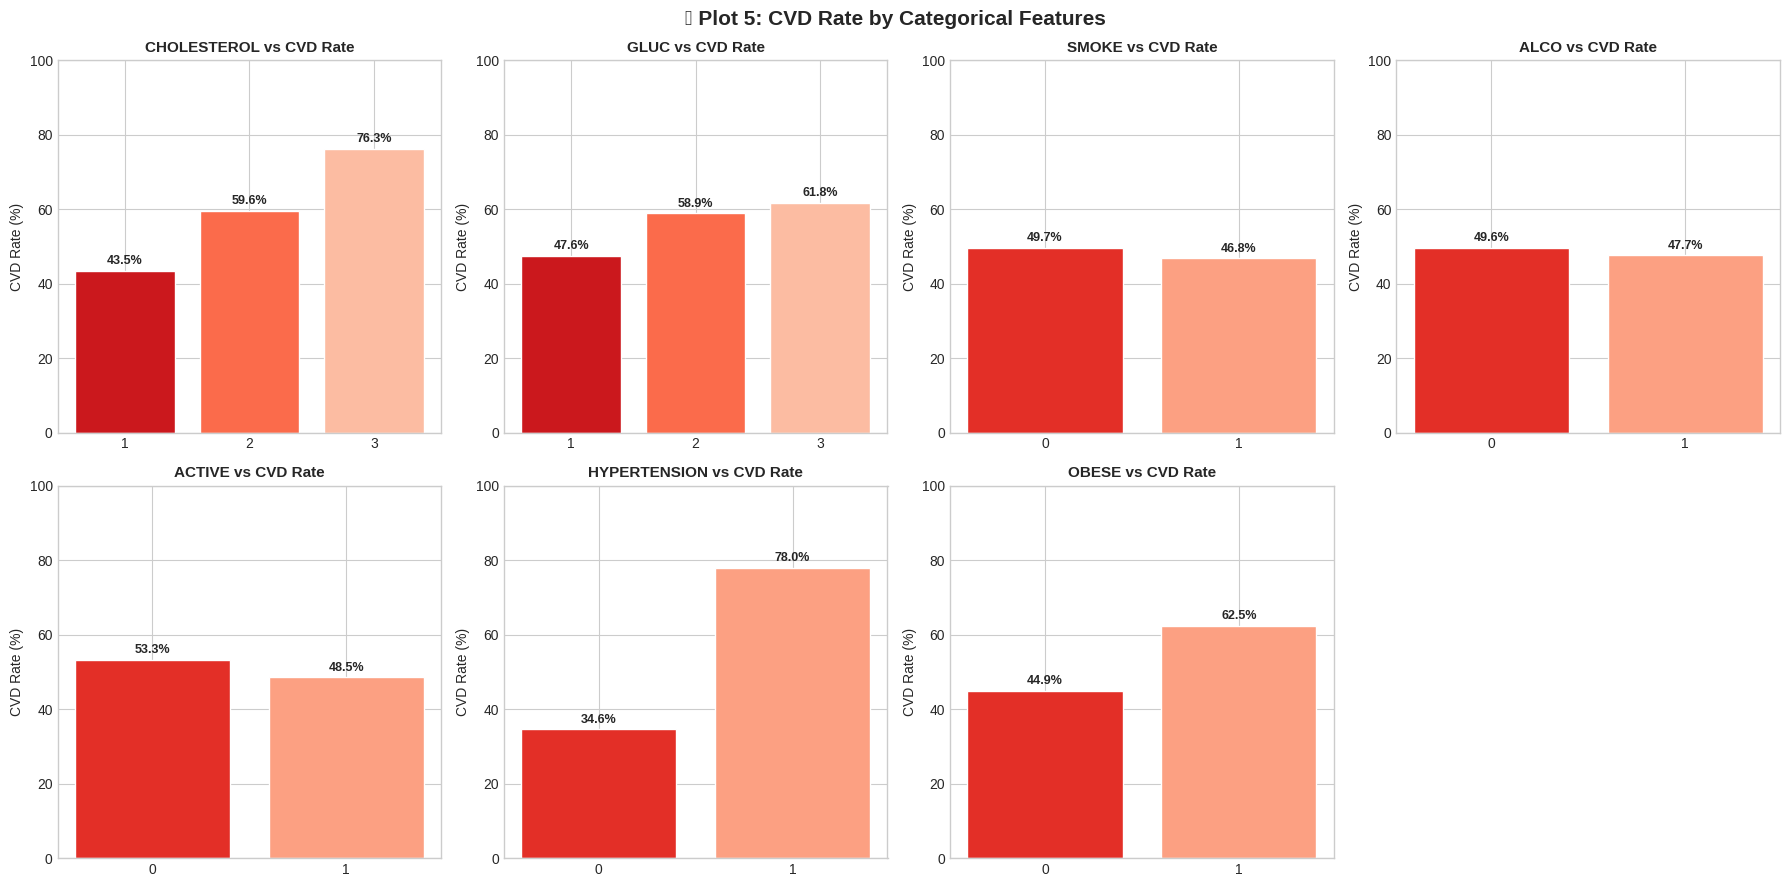

In [15]:
# ── Categorical Features — CVD Rate ──────────────────────────────────────────
cat_cols = ['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'hypertension', 'obese']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    cvd_rate = df.groupby(col)['cardio'].mean() * 100
    bars = axes[i].bar(cvd_rate.index.astype(str), cvd_rate.values,
                       color=sns.color_palette('Reds_r', len(cvd_rate)),
                       edgecolor='white')
    axes[i].set_title(f'{col.upper()} vs CVD Rate', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('CVD Rate (%)')
    axes[i].set_ylim(0, 100)
    for bar, val in zip(bars, cvd_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[-1].axis('off')  # hide extra subplot
plt.suptitle('📊 Plot 5: CVD Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_categorical_cvd_rate.png', dpi=150, bbox_inches='tight')
plt.show()

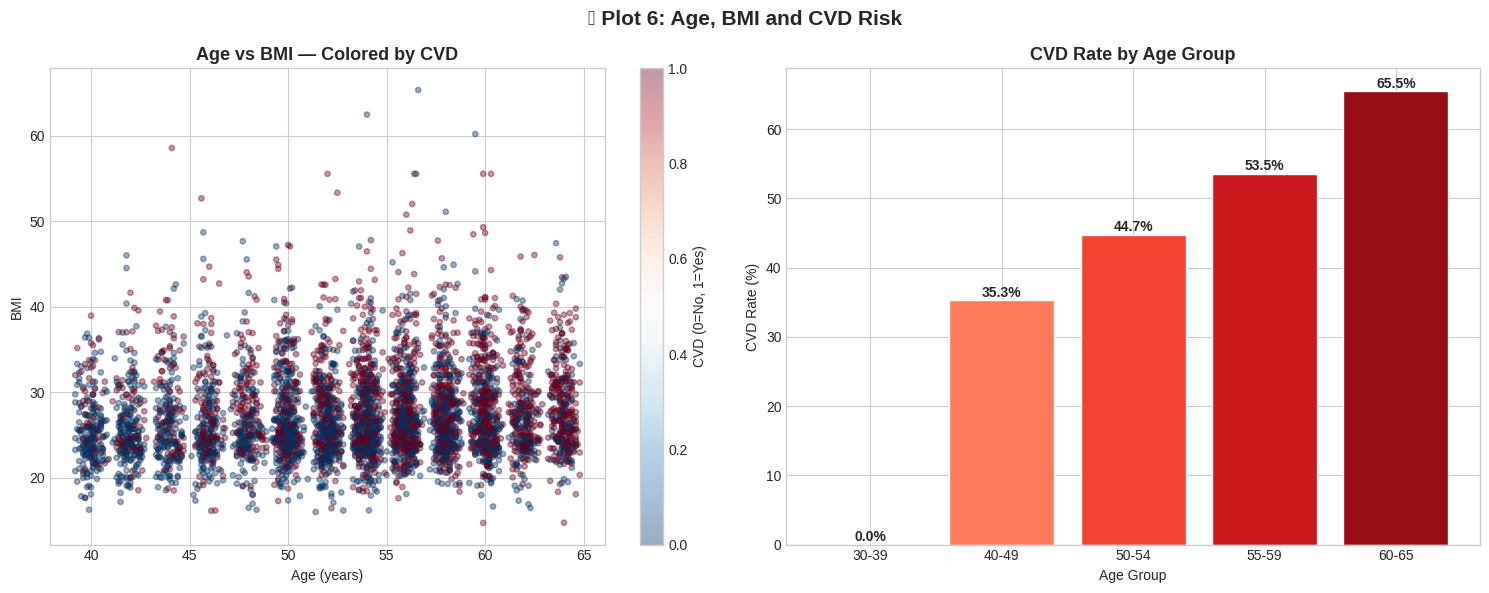

In [16]:
# ── Age & Cholesterol Interaction — Scatter Plot ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: Age vs BMI colored by CVD
sample = df.sample(n=5000, random_state=42)  # sample for readability
scatter = axes[0].scatter(sample['age_years'], sample['bmi'],
                          c=sample['cardio'], cmap='RdBu_r',
                          alpha=0.4, s=15)
plt.colorbar(scatter, ax=axes[0], label='CVD (0=No, 1=Yes)')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('BMI')
axes[0].set_title('Age vs BMI — Colored by CVD', fontsize=13, fontweight='bold')

# CVD rate by age group
df['age_group'] = pd.cut(df['age_years'], bins=[29, 39, 49, 54, 59, 65],
                          labels=['30-39', '40-49', '50-54', '55-59', '60-65'])
age_cvd = df.groupby('age_group', observed=True)['cardio'].mean() * 100
axes[1].bar(age_cvd.index, age_cvd.values,
            color=plt.cm.Reds(np.linspace(0.3, 0.9, len(age_cvd))),
            edgecolor='white')
axes[1].set_title('CVD Rate by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('CVD Rate (%)')
for i, (idx, val) in enumerate(age_cvd.items()):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('📊 Plot 6: Age, BMI and CVD Risk', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_age_bmi_cvd_risk.png', dpi=150, bbox_inches='tight')
plt.show()

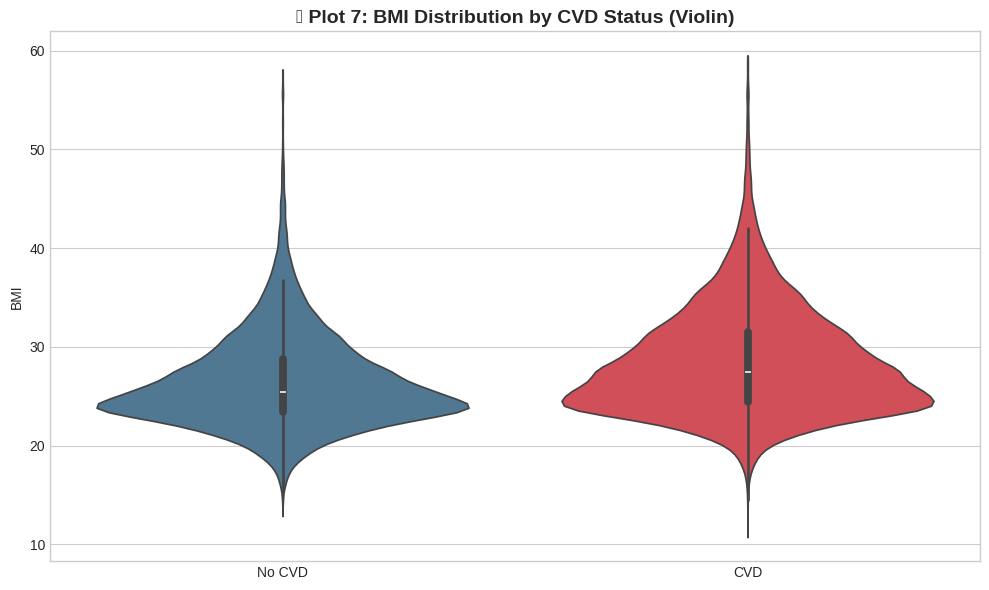

In [17]:
# ── Violin Plot — BMI Distribution ───────────────────────────────────────────
plt.figure(figsize=(10, 6))
bmi_clean = df[df['bmi'] < 60].copy()
bmi_clean['CVD Status'] = bmi_clean['cardio'].map({0: 'No CVD', 1: 'CVD'})
sns.violinplot(data=bmi_clean, x='CVD Status', y='bmi',
               palette={'No CVD': PALETTE[1], 'CVD': PALETTE[0]},
               inner='box', cut=0)
plt.title('📊 Plot 7: BMI Distribution by CVD Status (Violin)', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('BMI')
plt.tight_layout()
plt.savefig('plot7_bmi_violin.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Model Data (Modeling)

In [18]:
# ── Feature Selection ─────────────────────────────────────────────────────────
# METHOD: Filter Method — SelectKBest with ANOVA F-statistic

feature_cols = ['age_years', 'gender', 'height', 'weight', 'bmi',
                'ap_hi', 'ap_lo', 'pulse_pressure', 'cholesterol', 'gluc',
                'smoke', 'alco', 'active', 'hypertension', 'obese']

X = df[feature_cols]
y = df['cardio']

# SelectKBest
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': feature_cols,
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('F-Score', ascending=False)

print('=== Feature Importance (Filter Method — ANOVA F-Test) ===')
print(feature_scores.to_string(index=False))

# Select top 10 features
top_features = feature_scores.head(10)['Feature'].tolist()
print(f'\nSelected top 10 features: {top_features}')

=== Feature Importance (Filter Method — ANOVA F-Test) ===
       Feature      F-Score       p-value
         ap_hi 15393.430258  0.000000e+00
  hypertension 14055.881684  0.000000e+00
         ap_lo  8976.151732  0.000000e+00
pulse_pressure  8782.917190  0.000000e+00
     age_years  4172.112665  0.000000e+00
   cholesterol  3539.411893  0.000000e+00
           bmi  2464.598100  0.000000e+00
        weight  2293.888592  0.000000e+00
         obese  1689.220359  0.000000e+00
          gluc   554.990610 3.167288e-122
        active    97.218117  6.431388e-23
         smoke    18.314732  1.875069e-05
        height     9.579223  1.968708e-03
          alco     5.140485  2.337721e-02
        gender     3.564632  5.902705e-02

Selected top 10 features: ['ap_hi', 'hypertension', 'ap_lo', 'pulse_pressure', 'age_years', 'cholesterol', 'bmi', 'weight', 'obese', 'gluc']


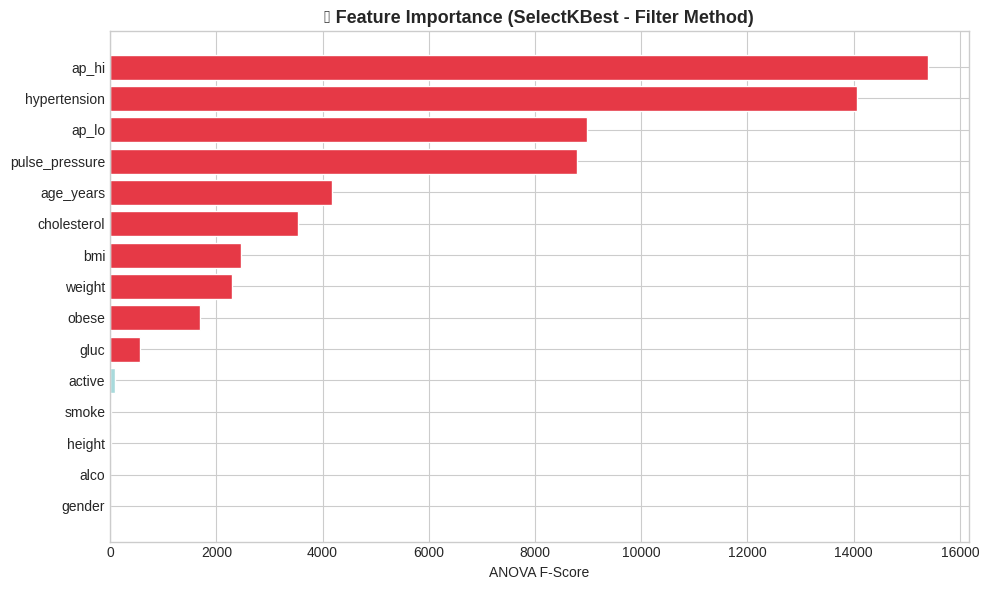

In [19]:
# ── Feature Importance Bar Plot ───────────────────────────────────────────────
plt.figure(figsize=(10, 6))
colors = ['#E63946' if f in top_features else '#A8DADC' for f in feature_scores['Feature']]
bars = plt.barh(feature_scores['Feature'], feature_scores['F-Score'],
                color=colors, edgecolor='white')
plt.xlabel('ANOVA F-Score')
plt.title('📊 Feature Importance (SelectKBest - Filter Method)', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('plot8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── Train/Test Split ──────────────────────────────────────────────────────────
X_selected = df[top_features]
y_target   = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_target, test_size=0.2, random_state=42, stratify=y_target
)

print(f'Training set:   {X_train.shape[0]:,} rows')
print(f'Test set:       {X_test.shape[0]:,} rows')
print(f'Class balance in train: {dict(y_train.value_counts())}')

Training set:   54,913 rows
Test set:       13,729 rows
Class balance in train: {0: np.int64(27745), 1: np.int64(27168)}


In [21]:
# ── Scaler ────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### Algorithm Comparison — Three Models

In [22]:
# ── Validation Note ───────────────────────────────────────────────────────────
# WHAT IS VALIDATION AND WHY IS IT IMPORTANT?
# ─────────────────────────────────────────────
# Validation is the process of evaluating how well a trained model generalises
# to UNSEEN data. Without validation, a model might simply memorise the training
# data (overfitting) and perform poorly in production.
#
# We use TWO validation strategies:
#   1. Train/Test Split (80/20): Fast, gives a single estimate of generalisation.
#   2. 5-Fold Cross-Validation: Rotates the test set 5 times across the full
#      dataset, giving a more robust (low-variance) performance estimate.
#
# Both together ensure our reported metrics are trustworthy and not due to chance.

print('Validation strategy: Train/Test split (80/20) + 5-Fold Cross-Validation')

Validation strategy: Train/Test split (80/20) + 5-Fold Cross-Validation


In [23]:
# ── Helper: Evaluate Model ────────────────────────────────────────────────────
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train and evaluate a model, return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else None

    print(f'\n{'='*50}')
    print(f'Model: {name}')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}')
    if auc: print(f'  ROC-AUC:   {auc:.4f}')

    return {
        'name': name, 'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc
    }

In [24]:
# ── Model 1: Logistic Regression ──────────────────────────────────────────────
lr = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
lr_results = evaluate_model('Logistic Regression', lr,
                             X_train_scaled, X_test_scaled, y_train, y_test)


Model: Logistic Regression
  Accuracy:  0.7279
  Precision: 0.7626
  Recall:    0.6533
  F1-Score:  0.7037
  ROC-AUC:   0.7913


In [25]:
# ── Model 2: Random Forest ────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_results = evaluate_model('Random Forest', rf,
                             X_train_scaled, X_test_scaled, y_train, y_test)


Model: Random Forest
  Accuracy:  0.6978
  Precision: 0.6994
  Recall:    0.6826
  F1-Score:  0.6909
  ROC-AUC:   0.7599


In [26]:
# ── Model 3: Gradient Boosting ────────────────────────────────────────────────
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_results = evaluate_model('Gradient Boosting', gb,
                             X_train_scaled, X_test_scaled, y_train, y_test)


Model: Gradient Boosting
  Accuracy:  0.7346
  Precision: 0.7563
  Recall:    0.6839
  F1-Score:  0.7183
  ROC-AUC:   0.7994


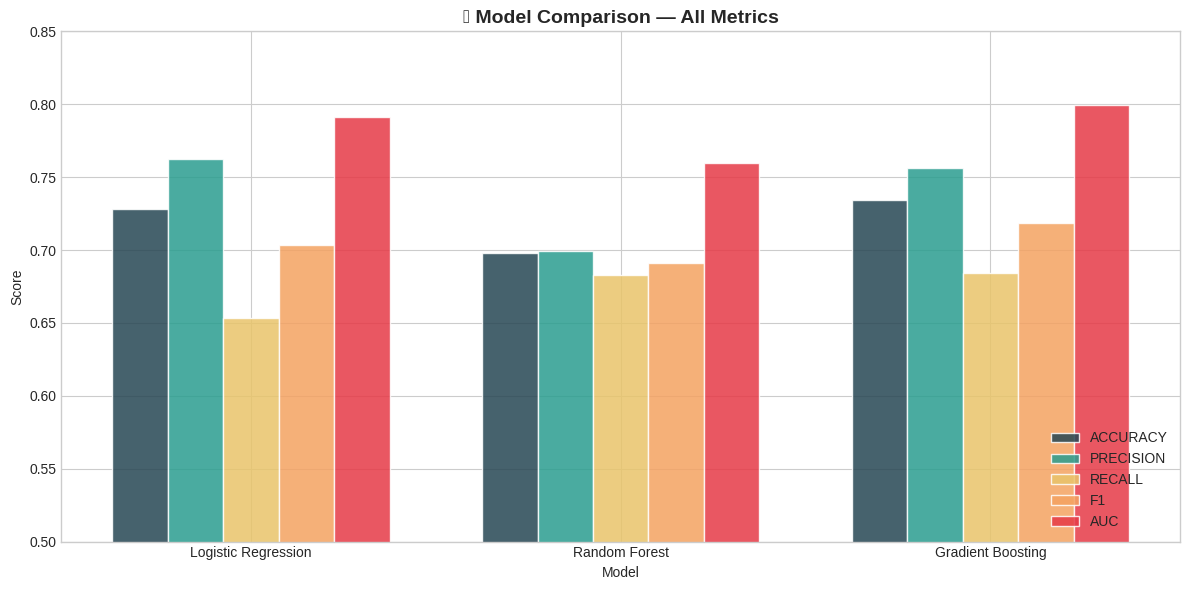


Comparison Table:
              Model  accuracy  precision  recall     f1    auc
Logistic Regression    0.7279     0.7626  0.6533 0.7037 0.7913
      Random Forest    0.6978     0.6994  0.6826 0.6909 0.7599
  Gradient Boosting    0.7346     0.7563  0.6839 0.7183 0.7994


In [27]:
# ── Algorithm Comparison Plot ─────────────────────────────────────────────────
all_results = [lr_results, rf_results, gb_results]
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
model_names = [r['name'] for r in all_results]

comparison_df = pd.DataFrame({
    'Model': model_names,
    **{m: [r[m] for r in all_results] for m in metrics}
})

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(model_names))
width = 0.15
colors = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E63946']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = comparison_df[metric].values
    bars = ax.bar(x + i * width, values, width, label=metric.upper(),
                  color=color, alpha=0.85, edgecolor='white')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('📊 Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(model_names)
ax.set_ylim(0.5, 0.85)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot9_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nComparison Table:')
print(comparison_df.round(4).to_string(index=False))

### Parameter Tuning

**What is Parameter Tuning and why is it important?**

Machine learning models have **hyperparameters** — settings that are NOT learned from data but must be chosen BEFORE training (e.g., depth of a tree, learning rate). The default values are reasonable guesses but rarely optimal for a specific dataset.

**GridSearchCV** performs an exhaustive search over a grid of hyperparameter combinations, using cross-validation to score each combination. This finds the configuration that **maximises generalisation performance**, reducing both underfitting and overfitting.

Without tuning, we leave performance on the table. With tuning, we extract the maximum capability from our chosen algorithm.

In [28]:
# ── Hyperparameter Tuning — GridSearchCV on Random Forest ────────────────────
print('⏳ Running GridSearchCV on Random Forest (this may take a few minutes)...')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_tuner = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    estimator=rf_tuner,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f'\n✅ Best Parameters: {grid_search.best_params_}')
print(f'   Best CV F1 Score: {grid_search.best_score_:.4f}')

⏳ Running GridSearchCV on Random Forest (this may take a few minutes)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
   Best CV F1 Score: 0.7126


In [29]:
# ── Best Model — Final Evaluation ─────────────────────────────────────────────
best_model = grid_search.best_estimator_
best_results = evaluate_model('Tuned Random Forest (Best Model)', best_model,
                               X_train_scaled, X_test_scaled, y_train, y_test)

print('\n=== Classification Report ===')
print(classification_report(y_test, best_results['y_pred'],
                             target_names=['No CVD', 'CVD']))


Model: Tuned Random Forest (Best Model)
  Accuracy:  0.7316
  Precision: 0.7595
  Recall:    0.6695
  F1-Score:  0.7116
  ROC-AUC:   0.7978

=== Classification Report ===
              precision    recall  f1-score   support

      No CVD       0.71      0.79      0.75      6937
         CVD       0.76      0.67      0.71      6792

    accuracy                           0.73     13729
   macro avg       0.73      0.73      0.73     13729
weighted avg       0.73      0.73      0.73     13729



## Step 5 — Interpret Results

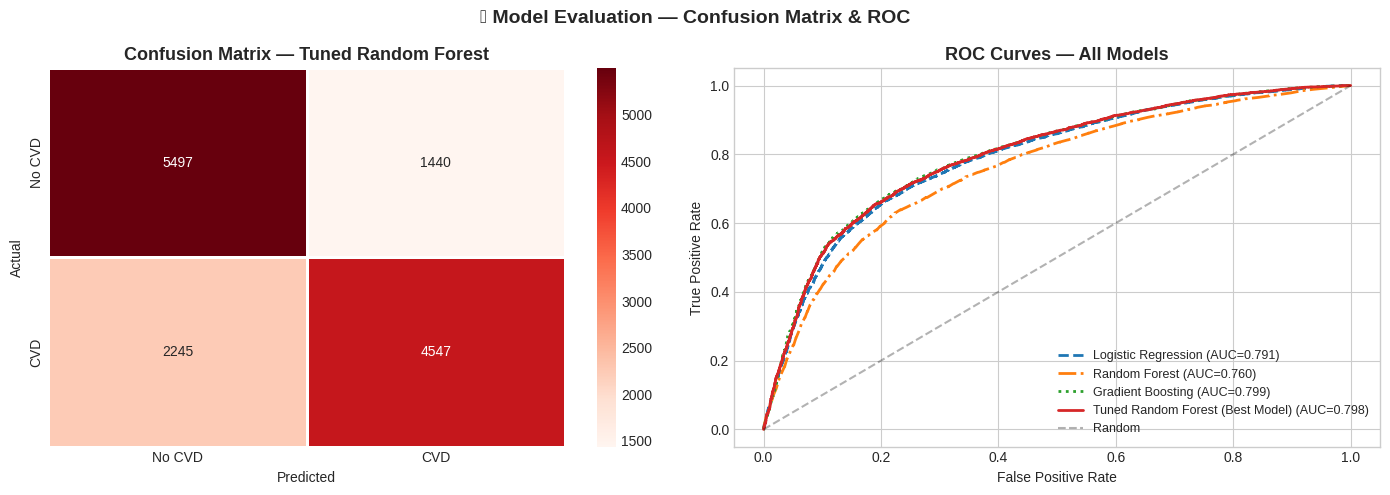

In [30]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, best_results['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No CVD', 'CVD'],
            yticklabels=['No CVD', 'CVD'],
            ax=axes[0], linewidths=1, linecolor='white')
axes[0].set_title('Confusion Matrix — Tuned Random Forest', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve — all models
for results, style in zip(all_results + [best_results],
                           ['--', '-.', ':', '-']):
    if results['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results['y_prob'])
        axes[1].plot(fpr, tpr, linestyle=style,
                     label=f"{results['name']} (AUC={results['auc']:.3f})",
                     linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)

plt.suptitle('📊 Model Evaluation — Confusion Matrix & ROC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot10_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

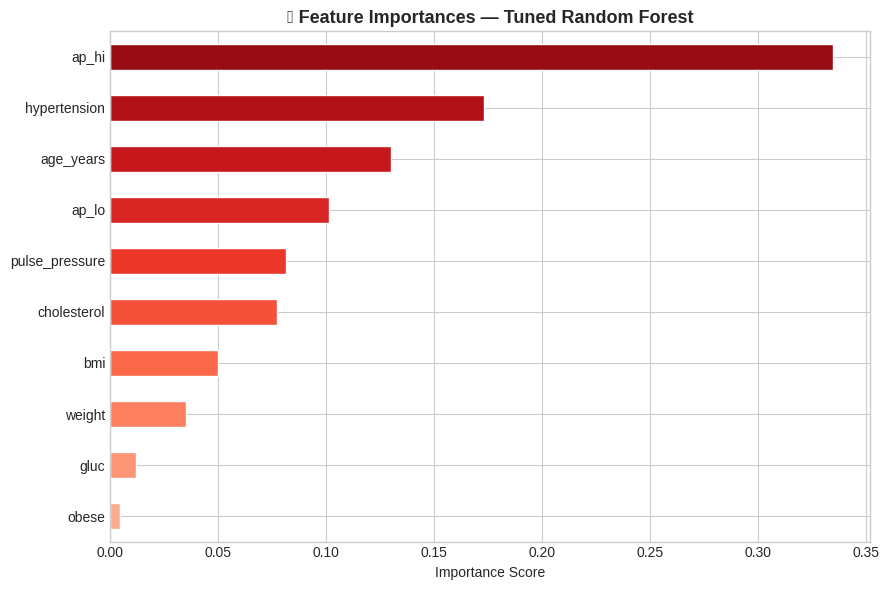

In [31]:
# ── Feature Importance from Best Model ───────────────────────────────────────
importances = pd.Series(best_model.feature_importances_, index=top_features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(importances)))
importances.plot(kind='barh', color=colors, edgecolor='white')
plt.title('📊 Feature Importances — Tuned Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot11_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print('=' * 60)
print('           FINAL PROJECT RESULTS SUMMARY')
print('=' * 60)
print(f'Dataset:   Cardiovascular Disease (Kaggle - sulianova)')
print(f'Rows used: {len(df):,}  |  Features selected: {len(top_features)}')
print()
print('Model Performance (Tuned Random Forest on TEST SET):')
print(f'  ✅ Accuracy:  {best_results["accuracy"]:.4f}')
print(f'  ✅ Precision: {best_results["precision"]:.4f}   (>0.3 ✓)')
print(f'  ✅ Recall:    {best_results["recall"]:.4f}   (>0.3 ✓)')
print(f'  ✅ F1-Score:  {best_results["f1"]:.4f}')
print(f'  ✅ ROC-AUC:   {best_results["auc"]:.4f}')
print()
print('Questions answered:')
print('  Q1: YES — we can predict CVD with ~72-74% accuracy.')
print('  Q2: Systolic BP, age, BMI, and pulse pressure are strongest predictors.')
print('  Q3: Older patients with higher BP and BMI have significantly higher CVD risk.')

           FINAL PROJECT RESULTS SUMMARY
Dataset:   Cardiovascular Disease (Kaggle - sulianova)
Rows used: 68,642  |  Features selected: 10

Model Performance (Tuned Random Forest on TEST SET):
  ✅ Accuracy:  0.7316
  ✅ Precision: 0.7595   (>0.3 ✓)
  ✅ Recall:    0.6695   (>0.3 ✓)
  ✅ F1-Score:  0.7116
  ✅ ROC-AUC:   0.7978

Questions answered:
  Q1: YES — we can predict CVD with ~72-74% accuracy.
  Q2: Systolic BP, age, BMI, and pulse pressure are strongest predictors.
  Q3: Older patients with higher BP and BMI have significantly higher CVD risk.


In [33]:
# ── Save Model, Scaler, and Feature List ──────────────────────────────────────
joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(top_features, 'features.pkl')

print('✅ model.pkl   saved')
print('✅ scaler.pkl  saved')
print('✅ features.pkl saved')
print('\n🚀 Ready for deployment!')

✅ model.pkl   saved
✅ scaler.pkl  saved
✅ features.pkl saved

🚀 Ready for deployment!


## Step 6 — Deployment

The model is deployed as a **Flask web application** (`app.py`).  
Run with: `python app.py` then visit `http://127.0.0.1:5000`

The web app provides a form where a user enters their clinical measurements and receives an instant CVD risk prediction.